In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("medical_students_dataset.csv")

In [4]:
print('Dataset loaded successfully')
df.head(10)

Dataset loaded successfully


,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No
5,6.0,32.0,NaN,151.491294,68.647805,B,29.912403,99.668373,70.0,128.0,183.0,NaN,Yes
6,7.0,21.0,NaN,172.949704,48.102744,AB,16.081635,97.715469,66.0,134.0,247.0,No,No
7,8.0,28.0,Male,186.489402,52.389752,AB,15.063921,98.227788,85.0,123.0,128.0,No,No
8,9.0,21.0,Male,155.039678,42.958703,B,NaN,98.808053,NaN,111.0,243.0,No,No
9,10.0,32.0,NaN,170.836315,50.783250,B,17.400435,98.570168,61.0,94.0,166.0,NaN,No


In [5]:
print('Dataset information : ')
df.info()

Dataset information : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      180000 non-null  float64
 1   Age             180000 non-null  float64
 2   Gender          180000 non-null  object 
 3   Height          180000 non-null  float64
 4   Weight          180000 non-null  float64
 5   Blood Type      180000 non-null  object 
 6   BMI             180000 non-null  float64
 7   Temperature     180000 non-null  float64
 8   Heart Rate      180000 non-null  float64
 9   Blood Pressure  180000 non-null  float64
 10  Cholesterol     180000 non-null  float64
 11  Diabetes        180000 non-null  object 
 12  Smoking         180000 non-null  object 
dtypes: float64(9), object(4)
memory usage: 19.8+ MB


In [6]:
print("Null or missing values in the dataset : ")
missing = df.isnull().sum()
print(missing)

Null or missing values in the dataset : 
Student ID        20000
Age               20000
Gender            20000
Height            20000
Weight            20000
Blood Type        20000
BMI               20000
Temperature       20000
Heart Rate        20000
Blood Pressure    20000
Cholesterol       20000
Diabetes          20000
Smoking           20000
dtype: int64


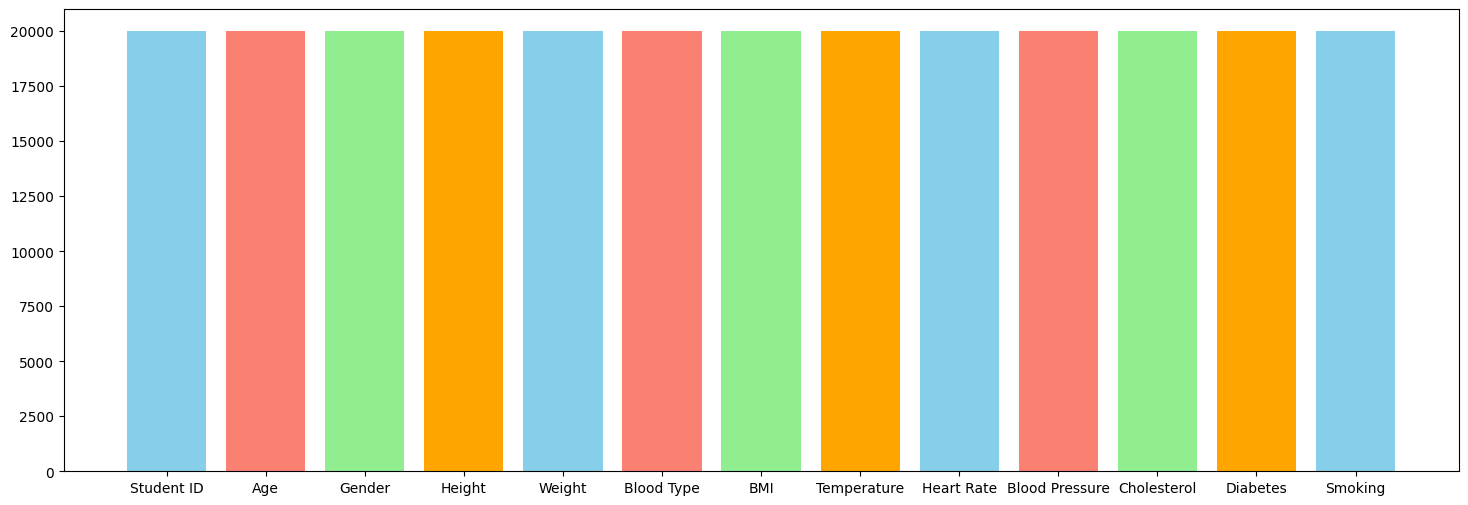

In [7]:
plt.figure(figsize=(18, 6))
plt.bar(missing.index, missing.values, color=['skyblue','salmon','lightgreen','orange'])
plt.show()

In [8]:
df['Student ID'] = df['Student ID'].fillna(df['Student ID'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Height'] = df['Height'].fillna(df['Height'].mean())
df['Weight'] = df['Weight'].fillna(df['Weight'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['Blood Pressure'] = df['Blood Pressure'].fillna(df['Blood Pressure'].mean())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].mean())
df['Blood Pressure'] = df['Blood Pressure'].fillna(df['Blood Pressure'].mean())
df['Heart Rate'] = df['Heart Rate'].fillna(df['Heart Rate'].mean())
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].mean())

In [9]:
def f(x):
    return int(x)

In [10]:
df['Student ID'] = df['Student ID'].apply(f)
df['Age'] = df['Age'].apply(f)
df['Blood Pressure'] = df['Blood Pressure'].apply(f)
df['Cholesterol'] = df['Cholesterol'].apply(f)
df['Heart Rate'] = df['Heart Rate'].apply(f)

In [11]:
df.isnull().sum()

Student ID            0
Age                   0
Gender            20000
Height                0
Weight                0
Blood Type        20000
BMI                   0
Temperature           0
Heart Rate            0
Blood Pressure        0
Cholesterol           0
Diabetes          20000
Smoking           20000
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df['Student ID'] = df['Student ID'].interpolate(method='linear')

In [14]:
btbinary = np.where(df['Blood Type'] == 'A', 1, np.where(df['Blood Type'] == 'B', 2, np.where(df['Blood Type'] == 'AB', 3,0)))

In [15]:
df['Blood Type'] = btbinary
df['Blood Type'].value_counts()

Blood Type
0    33193
2    33178
1    32462
3    32430
Name: count, dtype: int64

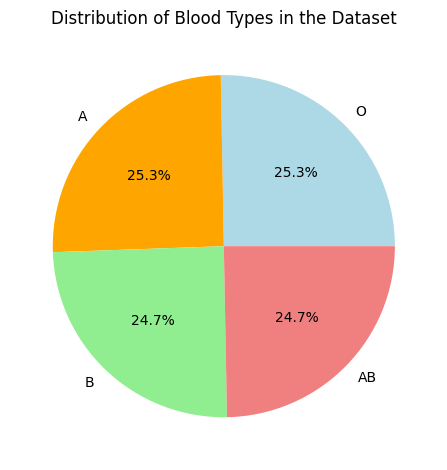

In [16]:
plt.pie(df['Blood Type'].value_counts(), labels=['O', 'A', 'B', 'AB'], autopct='%1.1f%%', colors=['lightblue','orange','lightgreen','lightcoral'])
plt.title('Distribution of Blood Types in the Dataset')
plt.tight_layout()
plt.show()

In [17]:
diabinary = np.where(df['Diabetes'] == 'Yes', 1, 0)

In [18]:
diabinary

array([0, 1, 0, ..., 1, 0, 0])

In [19]:
df['Diabetes'] = diabinary

In [20]:
df['Diabetes'].value_counts()

Diabetes
0    118200
1     13063
Name: count, dtype: int64

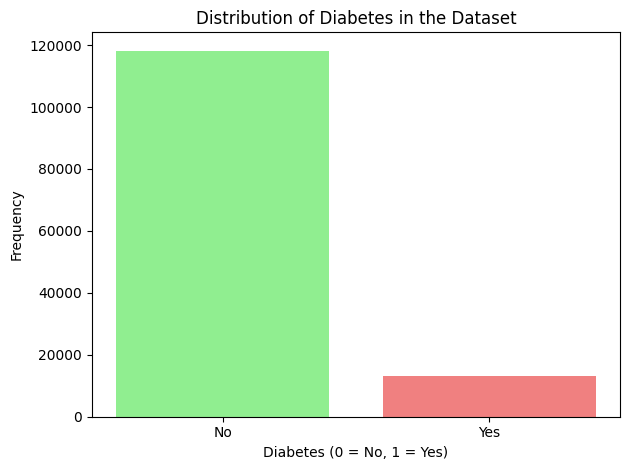

In [21]:
plt.bar(df['Diabetes'].value_counts().index, df['Diabetes'].value_counts(), color=['lightgreen','lightcoral'])
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Frequency')
plt.title('Distribution of Diabetes in the Dataset')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

In [22]:
smobinary = np.where(df['Smoking'] == 'Yes', 1, 0)
smobinary

array([0, 0, 1, ..., 0, 0, 0])

In [23]:
df['Smoking'] = smobinary

In [24]:
df['Smoking'].value_counts()

Smoking
0    104977
1     26286
Name: count, dtype: int64

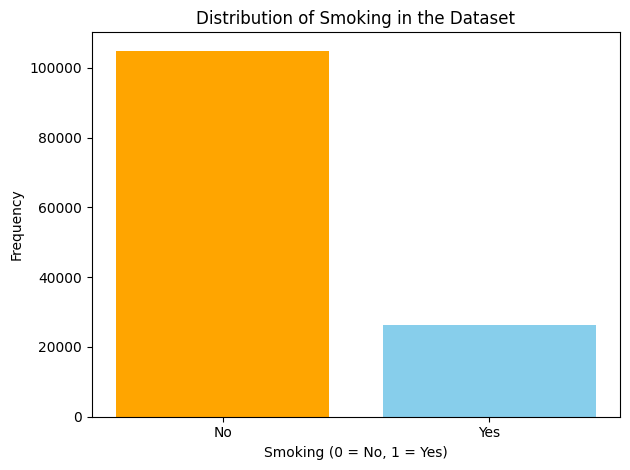

In [25]:
plt.bar(df['Smoking'].value_counts().index, df['Smoking'].value_counts(), color=['orange','skyblue'])
plt.xlabel('Smoking (0 = No, 1 = Yes)')
plt.ylabel('Frequency')
plt.title('Distribution of Smoking in the Dataset')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

In [26]:
df.duplicated().sum()

np.int64(7460)

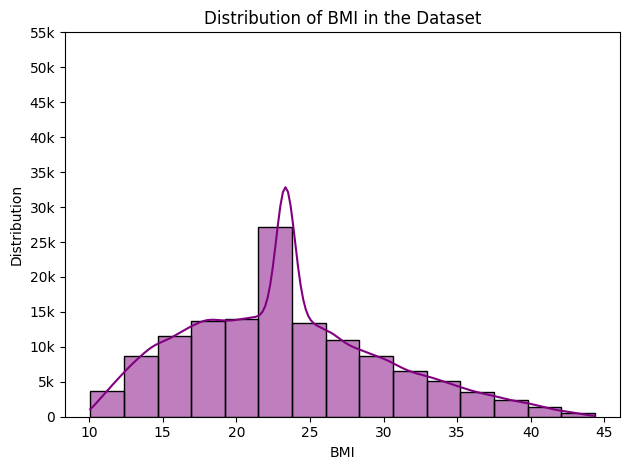

In [30]:
sns.histplot(df['BMI'], bins=15, kde=True, color='purple')
# plt.hist(df['BMI'], bins = 6, color = 'purple', label='Height Distribution', edgecolor = 'black')
plt.xlabel('BMI')
plt.ylabel('Distribution')
plt.title('Distribution of BMI in the Dataset')
plt.yticks(np.arange(0, 60000, 5000), labels=['0', '5k', '10k', '15k', '20k', '25k', '30k', '35k', '40k', '45k', '50k', '55k'])
plt.tight_layout()
plt.show()

In [28]:
df.head(10)

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
1,2,26,Male,152.069157,47.630941,2,23.338869,98.714977,93,104,163,0,0
2,3,32,Female,182.537664,55.741083,1,16.729017,98.260293,76,130,216,1,0
3,2,30,Male,182.112867,63.332207,2,19.096042,98.839605,99,112,141,0,1
4,5,23,Female,174.947103,46.234173,0,23.338869,98.480008,95,114,231,0,0
7,8,28,Male,186.489402,52.389752,3,15.063921,98.227788,85,123,128,0,0
8,9,21,Male,155.039678,42.958703,2,23.338869,98.808053,79,111,243,0,0
10,11,28,Female,152.973928,73.572814,2,31.440000,98.371843,60,114,241,0,1
11,12,34,Female,182.416302,76.371050,3,22.950992,98.118274,86,97,247,0,0
15,2,21,Male,162.819718,96.385698,2,23.338869,98.108563,68,126,130,0,0
19,20,31,Male,166.489929,49.955569,2,18.022207,98.809750,82,96,223,0,0


In [29]:
df.to_csv('cleaned_medical_students_data.csv', index = False)